# Phase 7 — Exploratory Data Analysis

**CineStock Production Rentals — synthetic dataset.** This notebook explores the cleaned demand data
(`data/processed/`) to understand distribution, trend, seasonality, category/location effects, SKU
volatility, and production-type effects, before any forecasting is attempted.

All data here is synthetic, generated in Phase 2 (see `src/generate_data.py`). Every chart below states
the business question it answers and the finding actually observed — not a conclusion decided in advance.

This notebook's code calls directly into `src/eda_analysis.py` rather than duplicating logic, consistent
with this project's convention of keeping reusable pipeline logic in `src/` and using notebooks for
narrative and exploration.

In [1]:
import sys
sys.path.insert(0, "../src")
import eda_analysis as eda

df = eda.load_data()
df.shape

(39000, 14)

## 1. Demand distribution

**Business question:** What does a typical week of demand look like across all SKU-location-weeks?

zero-demand weeks: 22.5% | weeks with >20 units: 1.9%


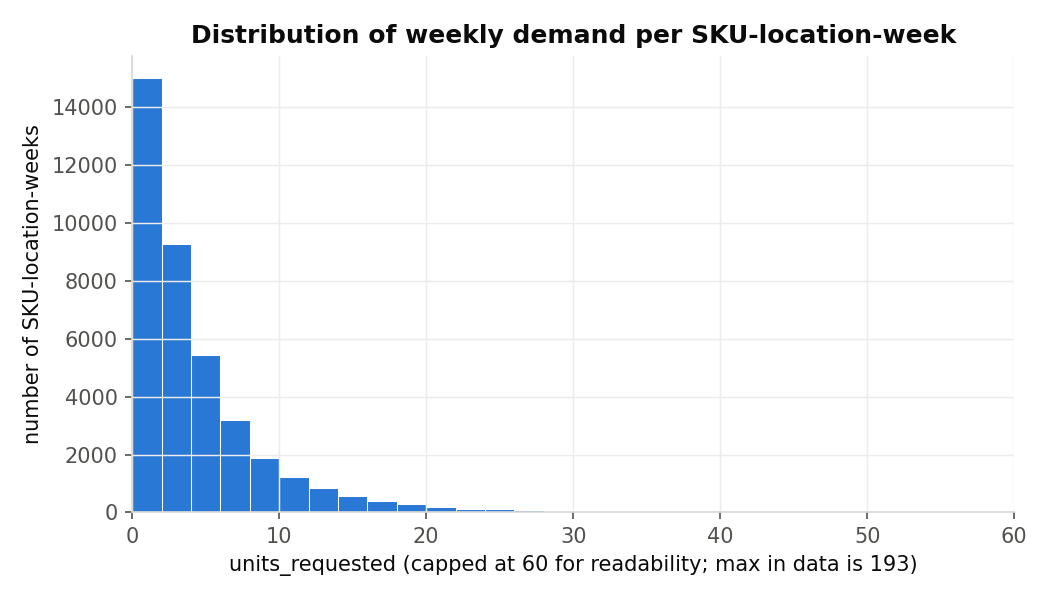

In [1]:
zero_pct, over_20_pct = eda.chart1_distribution(df)
print(f"zero-demand weeks: {zero_pct:.1f}% | weeks with >20 units: {over_20_pct:.1f}%")

**Finding:** 22.5% of SKU-location-weeks have zero demand, and demand is heavily
right-skewed — most weeks are small, but a long tail extends well past 20 units
(1.9% of weeks). Matches the spike/outlier pattern already investigated in Phase 2/3.

## 2. Demand trend over time

**Business question:** Is total company-wide demand trending up, down, or flat over the 2.5-year window,
and is there a repeating seasonal pattern?

2024 avg weekly total: 1194 | 2026 (partial) avg weekly total: 1390


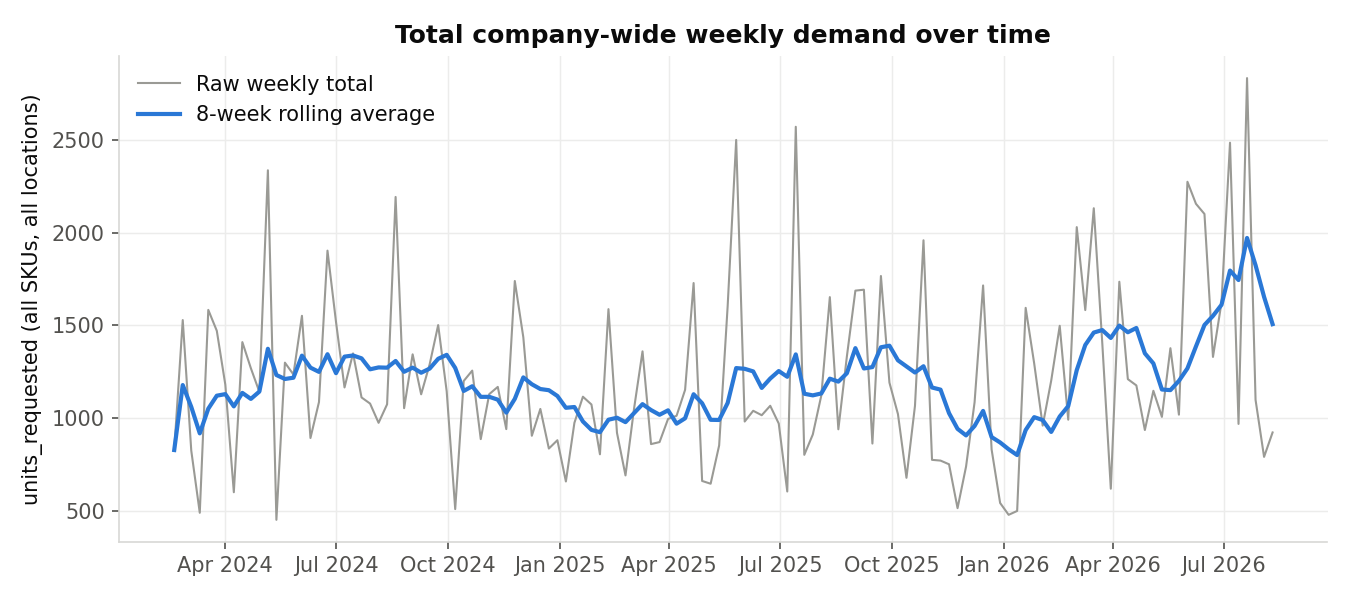

In [1]:
first_year_avg, last_year_avg = eda.chart2_trend(df)
print(f"2024 avg weekly total: {first_year_avg:.0f} | 2026 (partial) avg weekly total: {last_year_avg:.0f}")

**Finding:** demand grew from averaging ~1194 units/week in 2024 to
~1390/week by 2026, and a rise-and-fall seasonal cycle repeats visibly in each of the
three years shown.

## 3. Seasonality

**Business question:** Which months see the highest and lowest average demand?

peak month: 6 | trough month: 1


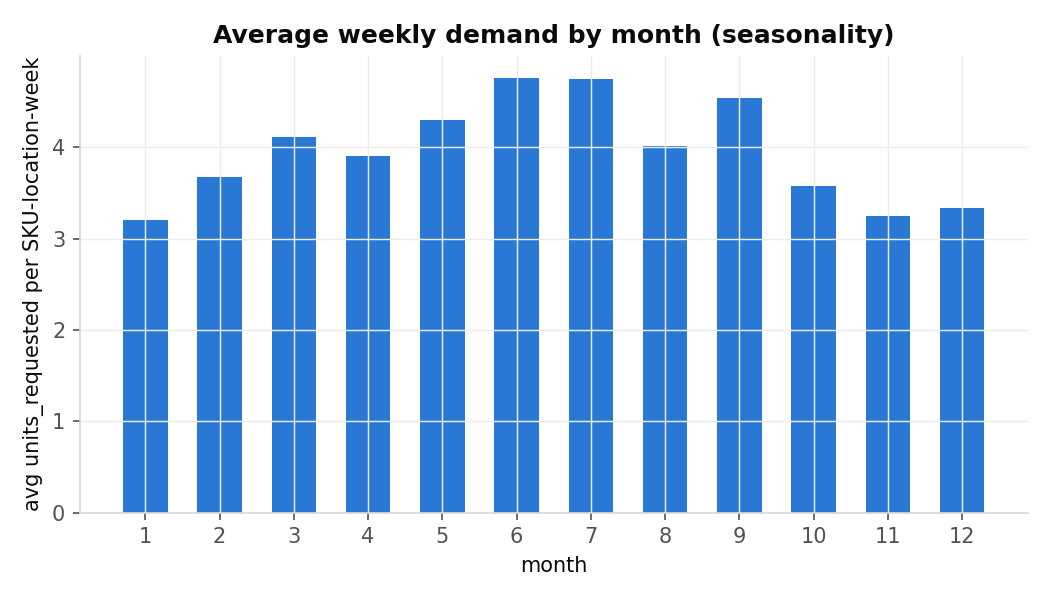

In [1]:
peak_month, trough_month = eda.chart3_seasonality(df)
print(f"peak month: {peak_month} | trough month: {trough_month}")

**Finding:** month 6 (June) is the peak, month 1 (January) is the trough --
consistent with a spring/summer production season and a winter-holiday slowdown.

## 4. Category & location demand

**Business question:** Which equipment categories and which rental locations drive the most demand?

category totals:
equipment_category
Battery     33653
Grip        31181
Lighting    30321
Audio       15201
Monitor     14341
Camera      13733
Lens        11861
Drone        6879

location totals:
location_id
LOC-01    44710
LOC-02    44546
LOC-03    40655
LOC-04    27259


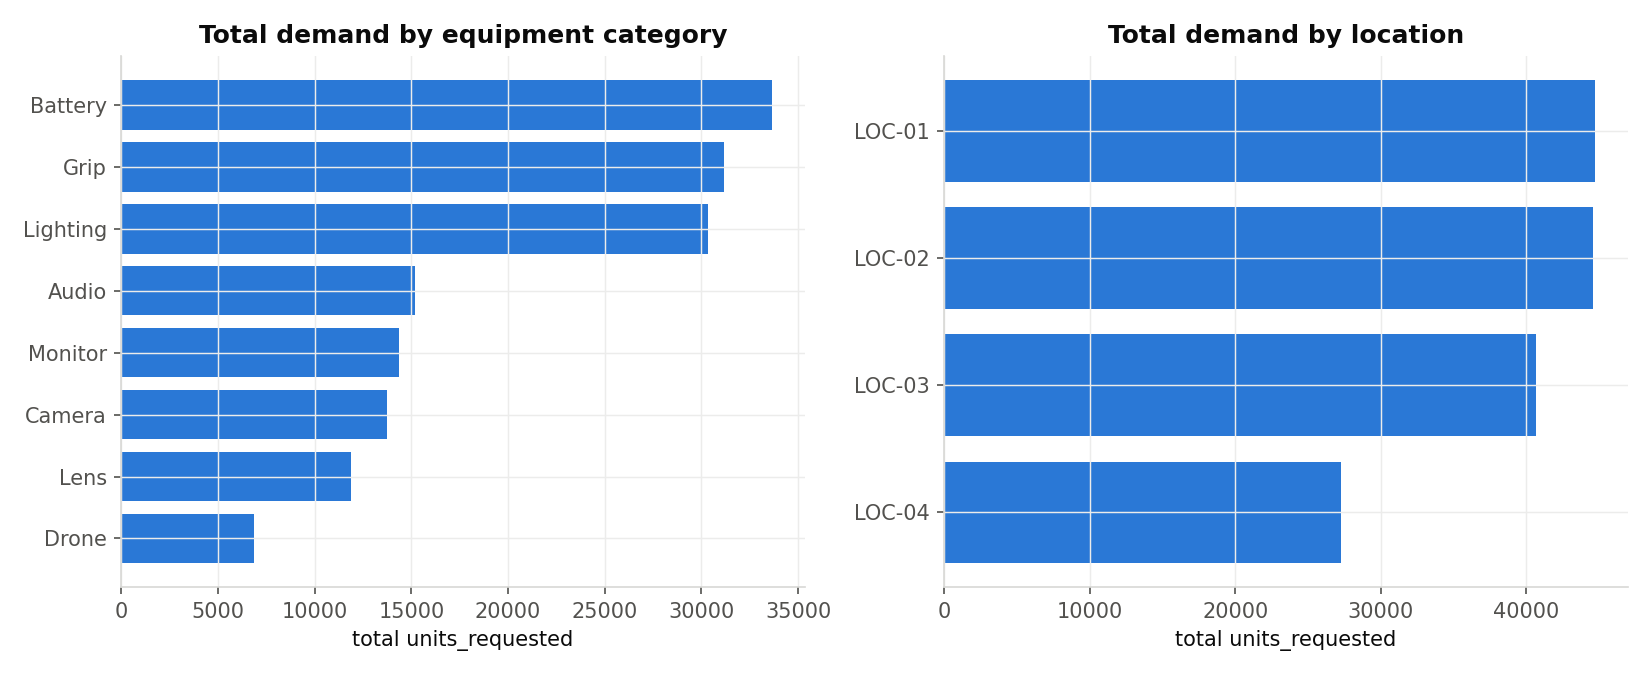

In [1]:
cat_totals, loc_totals = eda.chart4_category_location(df)
print("category totals:"); print(cat_totals)
print("location totals:"); print(loc_totals)

**Finding:** Battery leads all categories (33,653 total units), Drone is lowest
(6,879) -- roughly a 5x spread. Los Angeles and Atlanta lead locations closely, New
Orleans trails clearly. Worth noting: LA and Atlanta ended up nearly tied despite different underlying
activity levels (1.35 vs 1.15) -- a reminder that one simulation run doesn't reproduce input ratios exactly.

## 5. SKU volatility

**Business question:** Which SKUs have the most unpredictable (highest-variance-relative-to-mean) demand,
and therefore will likely be hardest to forecast accurately?

 sku_id           equipment_name     mean      std       cv
SKU-069          Compact Drone A 0.553846 1.081008 1.951820
SKU-070          FPV Drone Kit A 0.813462 1.580777 1.943272
SKU-006  Broadcast Camera Body A 1.611538 2.948998 1.829927
SKU-074   Drone Controller Kit A 1.019231 1.739160 1.706346
SKU-019       Vintage Lens Set A 1.757692 2.618840 1.489931
SKU-010    Large Format Camera B 3.288462 4.747321 1.443630
SKU-066 Client Viewing Monitor A 1.903846 2.733223 1.435632
SKU-044           Camera Dolly A 2.988462 4.162390 1.392820
SKU-037    Wireless Mic System B 4.305769 5.981407 1.389161
SKU-032     Shotgun Microphone A 1.611538 2.212911 1.373167


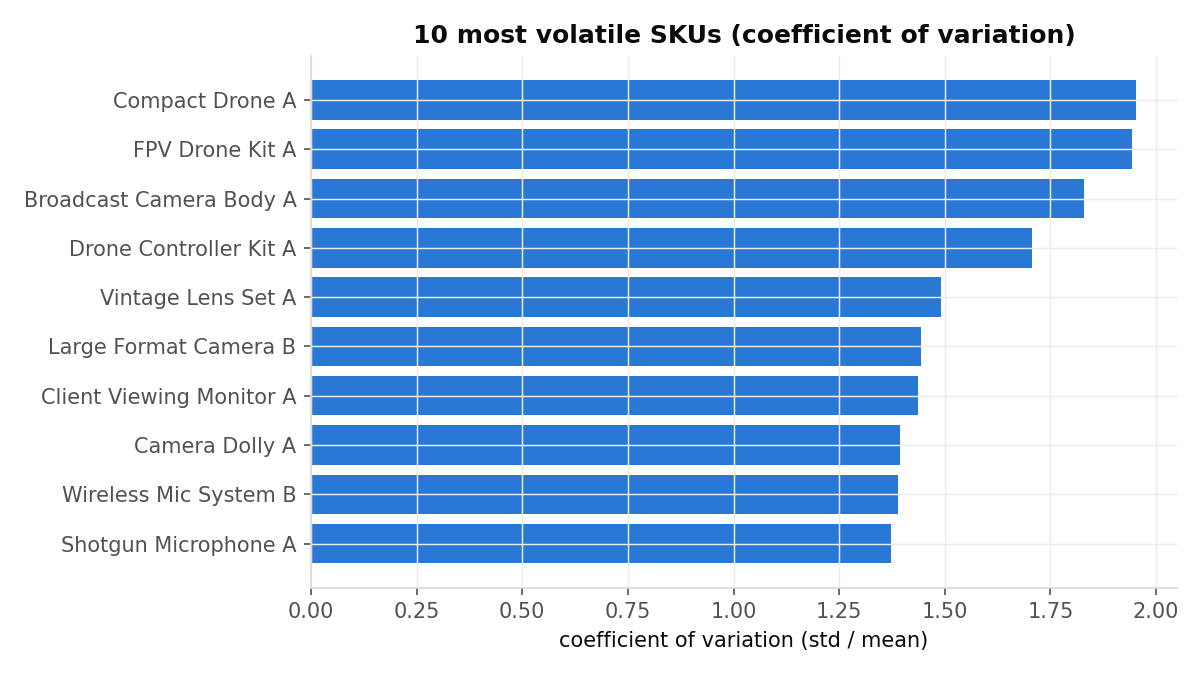

In [1]:
top10 = eda.chart5_volatility(df)
print(top10[["sku_id", "equipment_name", "mean", "std", "cv"]].to_string(index=False))

**Finding:** the most volatile SKUs are dominated by Drones and other niche, low-volume items
(top: Compact Drone A, CV 1.95). This is directly relevant to
Phase 9/10: low-volume, high-CV SKUs are the ones a forecasting model will struggle with most, and it's
better to know that going in than to be surprised by it during evaluation.

## 6. Category x production-type effects

**Business question:** Do different production types (Feature Film, Television, Commercial, Documentary,
Music Video) lean on different equipment categories differently?

production_type     Feature Film  Television  Commercial  Documentary  Music Video
equipment_category                                                                
Audio                       3.79        3.72        2.97         6.39         2.44
Battery                     9.34        9.07        7.93        13.89         7.88
Camera                      3.24        3.16        2.79         2.58         2.95
Drone                       1.75        1.31        1.92         1.63         2.09
Grip                        7.39        6.50        7.01         5.37         7.69
Lens                        2.91        2.76        2.40         1.87         2.63
Lighting                    5.74        5.40        7.44         3.99         6.05
Monitor                     4.38        4.13        3.70         3.60         3.03


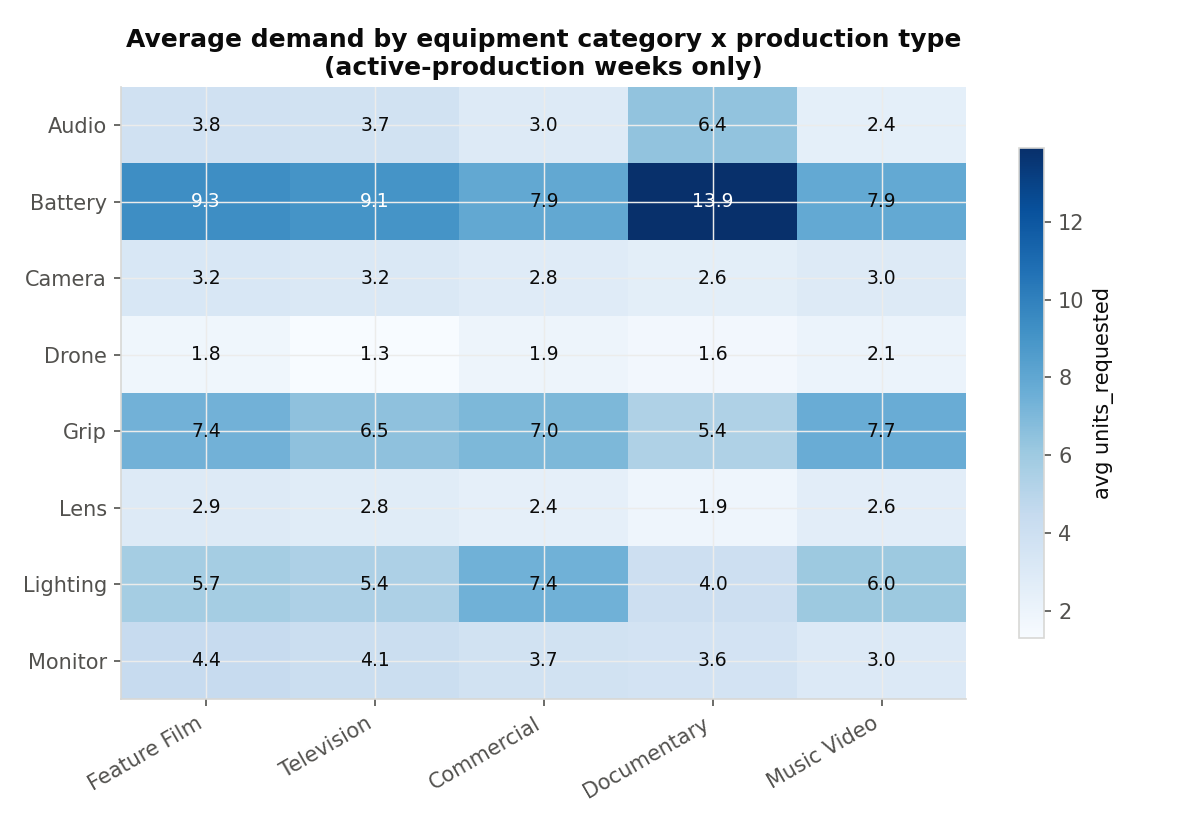

In [1]:
pivot = eda.chart6_production_heatmap(df)
print(pivot.round(2))

**Finding:** yes, clearly. Documentary productions show elevated Audio and Battery demand; Commercial
productions elevate Lighting; Music Video elevates Grip and Drone. **Important caveat:** this is the
category x production-type "affinity" table deliberately built into the synthetic data generator in
Phase 2 showing up correctly in the output -- it validates that the generation logic works as designed,
but it is confirming our own modeling assumption, not an independently discovered fact about real film
production. That distinction matters and is stated here explicitly rather than implied away.

## Summary

Six findings, each tied to a specific business question and observed directly from the data (not decided
in advance): a right-skewed, spiky demand distribution; a real upward trend plus repeating seasonality;
a June peak / January trough; Battery-led category demand with a ~5x category spread; Drone/niche-SKU
dominated volatility (a preview of what Phase 9/10 forecasting will find hardest); and clear, explainable
production-type effects on category demand -- with the caveat that the last finding reflects the synthetic
data's own design rather than an external discovery.

**Next:** Phase 8 -- establishing a naive/moving-average forecasting baseline before attempting anything
more sophisticated.